In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from load_data import get_dataset
from pipeline_tree_model import get_preprocessor
from print_metric import print_results

In [2]:
X_train, X_test, y_train, y_test = get_dataset()

In [3]:
preprocessor = get_preprocessor()

In [4]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

In [5]:
params_grid = {
    "model__loss": ["squared_error", "absolute_error"],
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 8],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__subsample": [0.7, 0.8, 1]
}

In [6]:
grid = RandomizedSearchCV(pipe, param_distributions=params_grid, cv=5, scoring="neg_mean_absolute_error", verbose=1, n_jobs=-1, n_iter=100, random_state=42)

In [7]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__loss': ['squared_error', 'absolute_error'], 'model__max_depth': [3, 4, ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for th

In [8]:
y_pred = grid.predict(X_test)

In [9]:
print("Training")
print_results(y_train, grid.predict(X_train))
print("\n")
print("Testing")
print_results(y_test, y_pred)

Training
R2 Score 0.862421855675323
MAE 1410.7340890278238
MSE 19961267.140957605
RMSE 4467.80339103654


Testing
R2 Score 0.8594540197925555
MAE 1610.7368895899665
MSE 21207143.134396482
RMSE 4605.121402785868


In [10]:
grid.best_params_

{'model__subsample': 1,
 'model__n_estimators': 300,
 'model__min_samples_leaf': 5,
 'model__max_depth': 5,
 'model__loss': 'absolute_error',
 'model__learning_rate': 0.05}

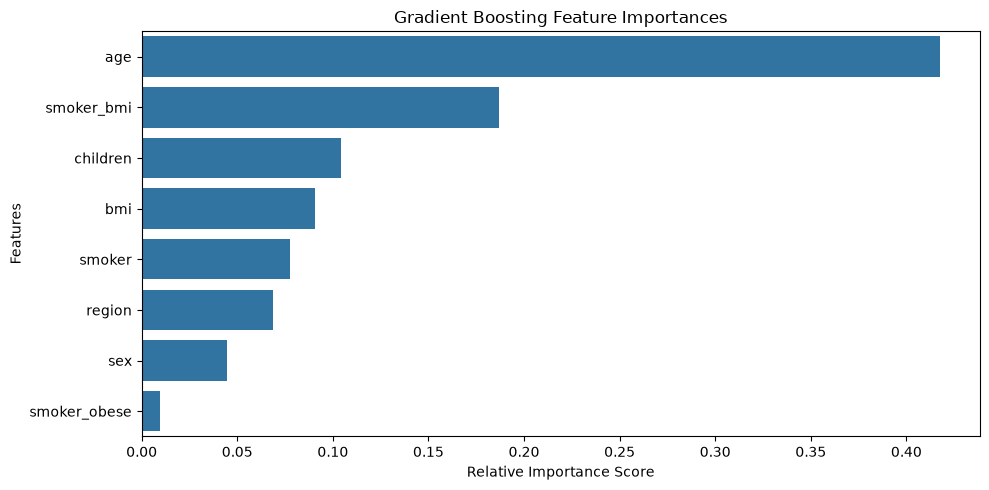

In [11]:
importances = grid.best_estimator_[-1].feature_importances_
outer_preprocessor = grid.best_estimator_[0]
column_transformer = outer_preprocessor.named_steps["column_transformer"]
feature_names = column_transformer.get_feature_names_out()
clean_feature_names = [name.split("__")[-1] for name in feature_names]
df_importances = pd.DataFrame(
    {"Feature": clean_feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Feature", data=df_importances)
plt.title("Gradient Boosting Feature Importances")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("images/gradient_boosting_feature_importances.png", dpi=1200)
plt.show()

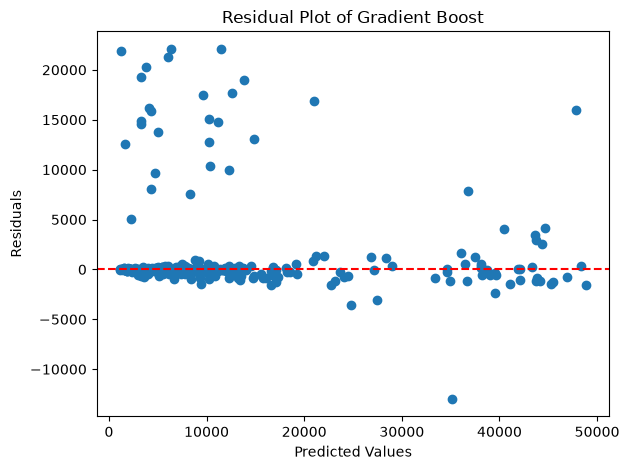

In [12]:
plt.title("Residual Plot of Gradient Boost")
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.savefig("images/residual_plot_of_gradient_boost.png", dpi=1200)
plt.show()